# Global Penetration Model: Distance To Center (Deterministic MLP)

This notebook mirrors the global VBLL workflow, but uses a plain deterministic MLP regressor with no Bayesian last layer. The goal is to compare predictive accuracy and diagnostics against the VBLL version directly.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "prepare_resum_data.py").exists() and (candidate / "README.md").exists():
            return candidate
    raise RuntimeError("Could not find the XLZD repo root.")


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)

EXPERIMENT_DIR = REPO_ROOT / "depth_penetration_experiments"
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

from depth_vbll import (
    component_summary_table,
    load_depth_dataset,
    plot_component_depth_heatmap,
    plot_component_initial_positions,
    plot_component_penetration_ranking,
    plot_prediction_parity,
    plot_target_distributions,
    plot_training_history,
    run_mlp_regression,
)

DATA_DIR = REPO_ROOT / "data"
MAX_ROWS_PER_COMPONENT = 25000
EPOCHS = 40
BATCH_SIZE = 512
ARTIFACT_DIR = EXPERIMENT_DIR / "artifacts" / "global_center_distance_mlp"

print(f"Repo root: {REPO_ROOT}")
print(f"Data dir: {DATA_DIR}")
print(f"Max rows per component: {MAX_ROWS_PER_COMPONENT}")
print(f"Artifact dir: {ARTIFACT_DIR}")


Repo root: /home/klz/Data/XLZD/anpatnaik
Data dir: /home/klz/Data/XLZD/anpatnaik/data
Max rows per component: 25000
Artifact dir: /home/klz/Data/XLZD/anpatnaik/depth_penetration_experiments/artifacts/global_center_distance_mlp


## 1. Load A Bounded Sample Of The Raw Events

In [2]:
dataset = load_depth_dataset(DATA_DIR, max_rows_per_component=MAX_ROWS_PER_COMPONENT)
df = dataset.df.copy()
summary_df = component_summary_table(df)

print(f"Rows loaded: {len(df):,}")
print(f"Fixed z_center: {dataset.z_center:.6f}")
print(f"Fixed TPC limits: R_max={dataset.r_max:.1f}, Z_max={dataset.z_max:.1f}")
print("Component grouping:")
for component, group in dataset.component_groups.items():
    print(f"  {component}: {group}")

display(summary_df)


Loading event files:   0%|          | 0/7 [00:00<?, ?it/s]

Rows loaded: 175,000
Fixed z_center: 1982.480000
Fixed TPC limits: R_max=1500.0, Z_max=2000.0
Component grouping:
  CathodeGrid: bottom
  FieldCage: side
  GXe: top
  ICV: side
  OCV: side
  TPCPMTTBottom: bottom
  TPCPMTTop: top


,source_component,component_group,event_count,sx_mean,sy_mean,sz_centered_mean,r_mean,z_from_center_mean,d_center_mean,d_center_p01
0,CathodeGrid,bottom,25000,-1.056260,-6.084838,-1982.463223,975.212240,1935.631314,2190.845045,1854.939150
5,TPCPMTTBottom,bottom,25000,1.353462,5.194269,-2168.176816,959.761045,1909.772723,2160.731303,1796.438459
1,FieldCage,side,25000,2.803467,-0.105762,-28.563942,1440.012288,1000.763246,1818.323291,1330.763068
3,ICV,side,25000,0.628476,2.374358,1355.627199,1239.223157,1432.794811,1994.127650,1338.655788
4,OCV,side,25000,-6.462084,-5.812304,1065.923900,1264.901704,1264.030796,1898.898488,1308.910685
2,GXe,top,25000,-4.507360,-3.219266,2382.752938,944.805380,1922.714918,2166.500981,1820.062119
6,TPCPMTTop,top,25000,1.575866,-3.365886,2087.215159,950.566568,1927.955807,2172.758594,1826.275596


## 2. Geometry And Target Visualizations

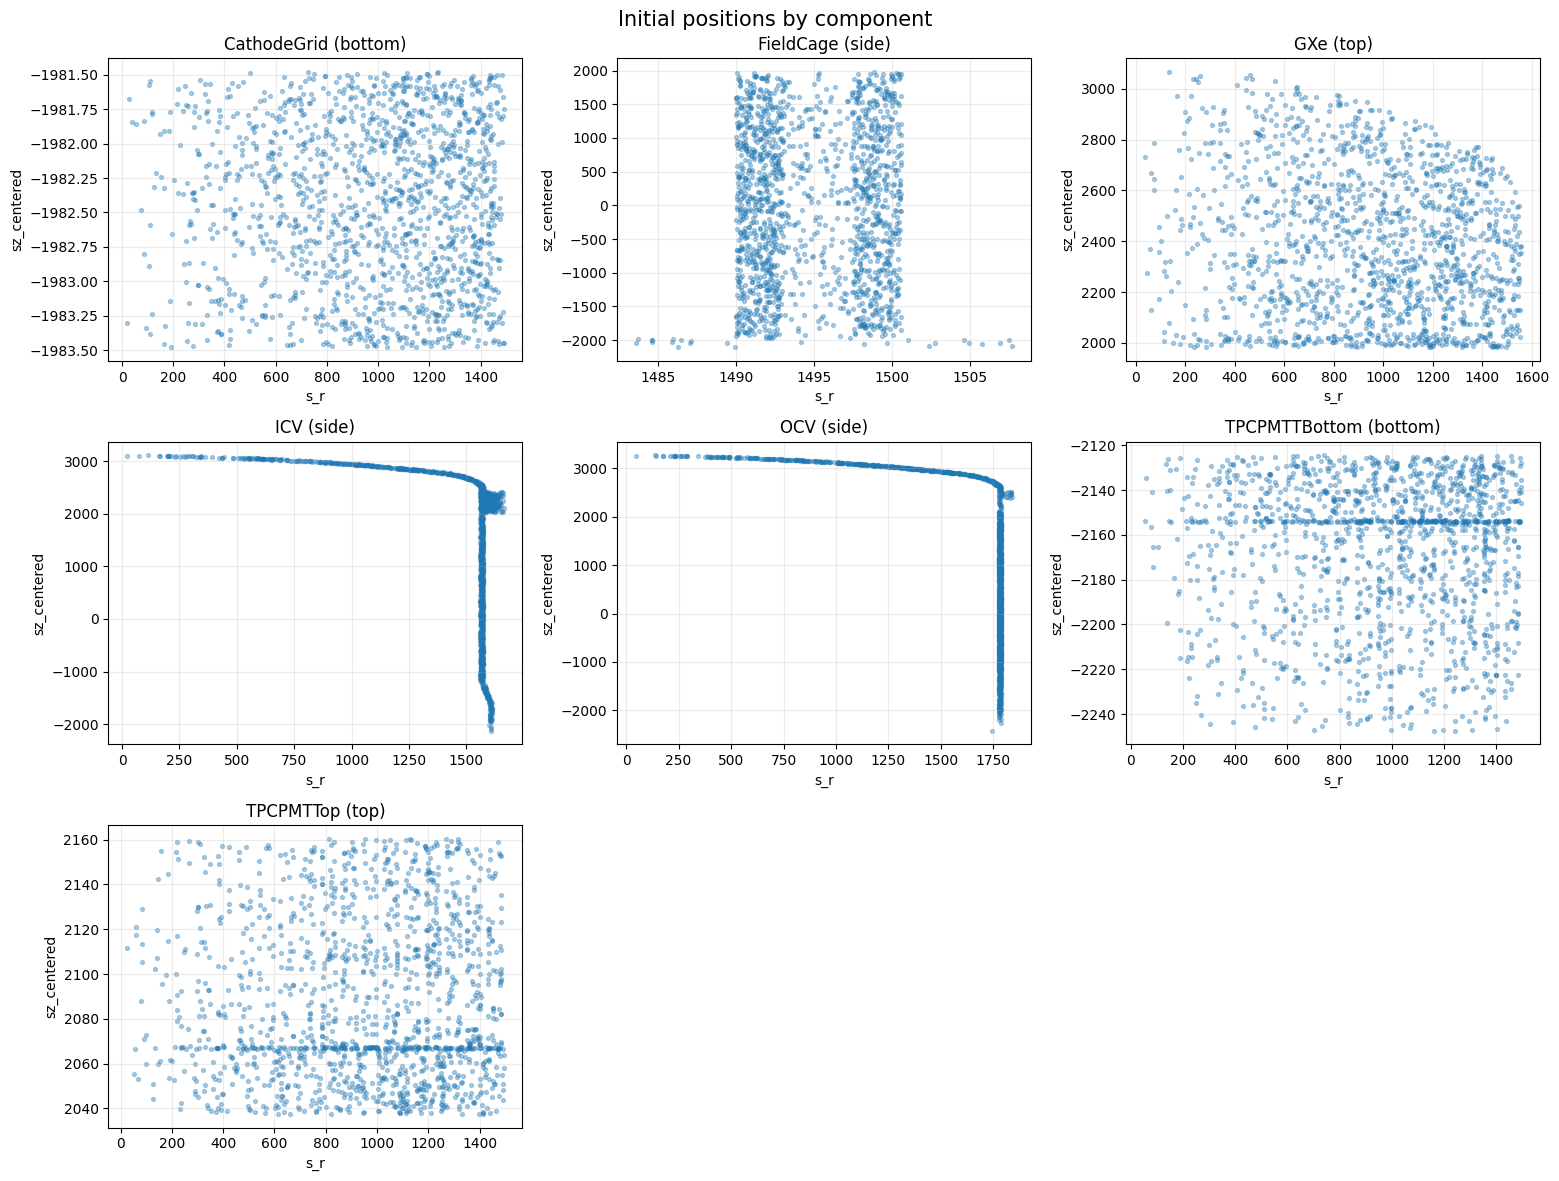

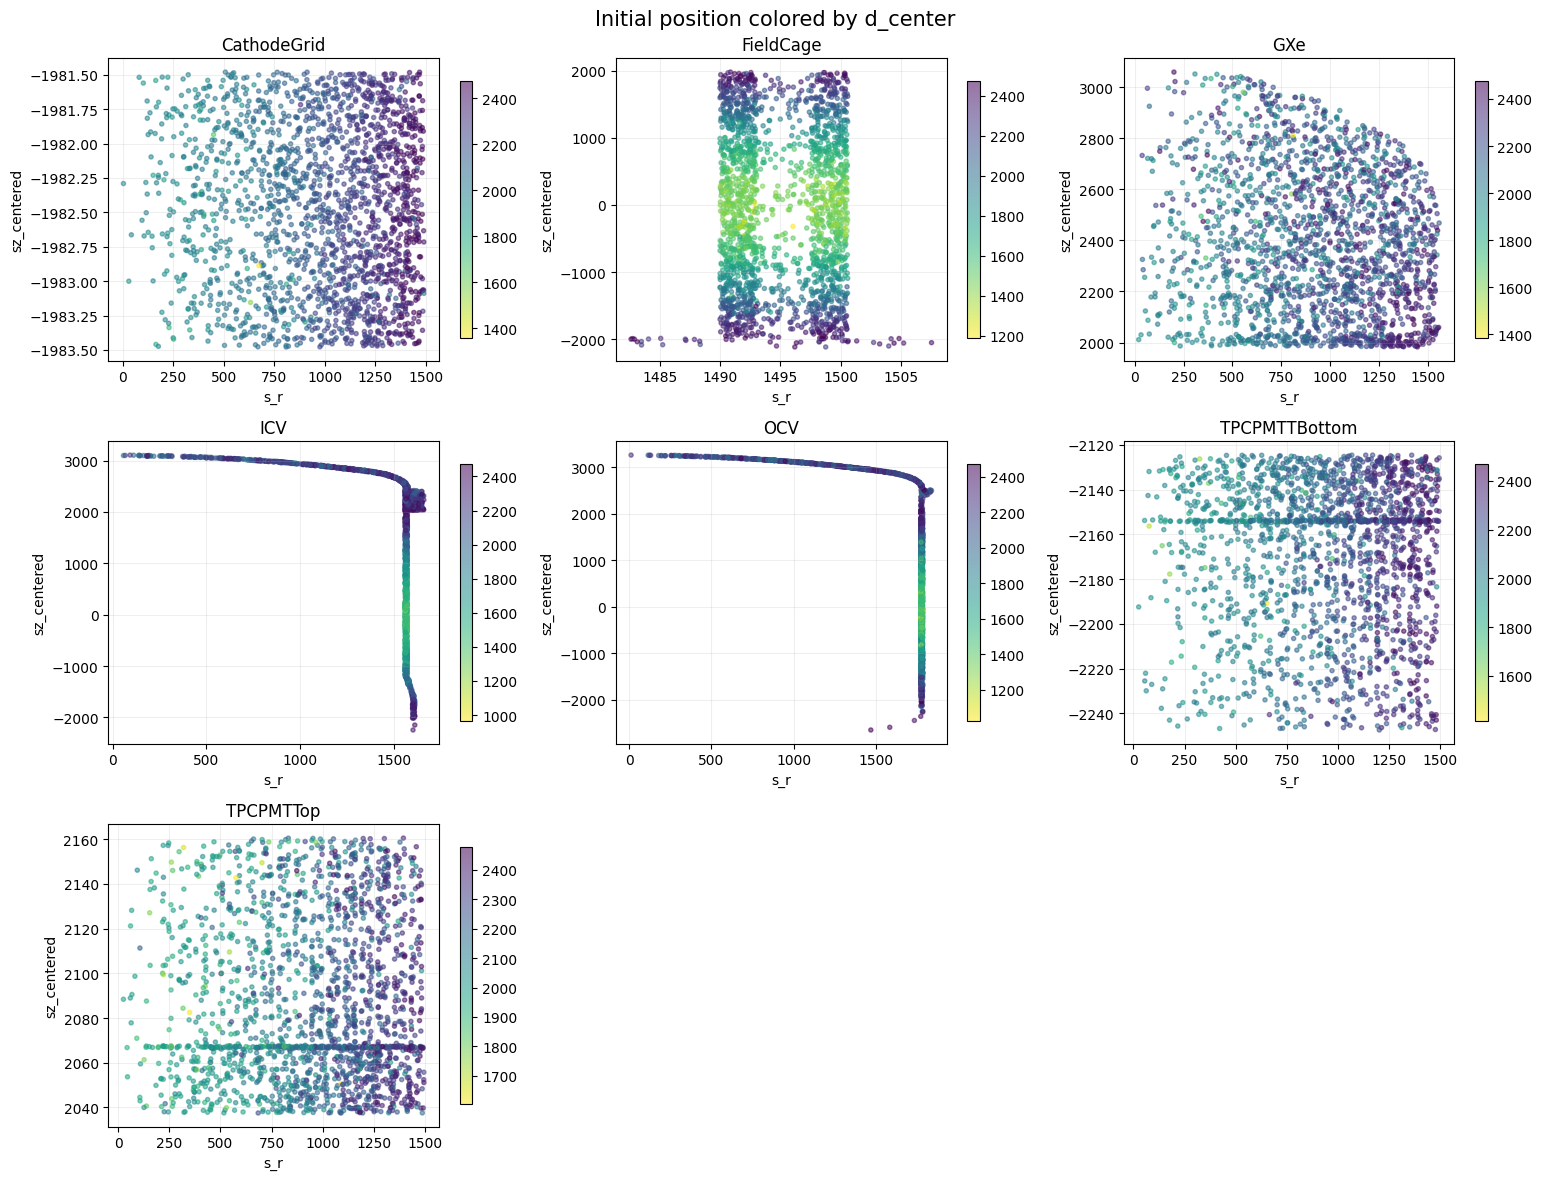

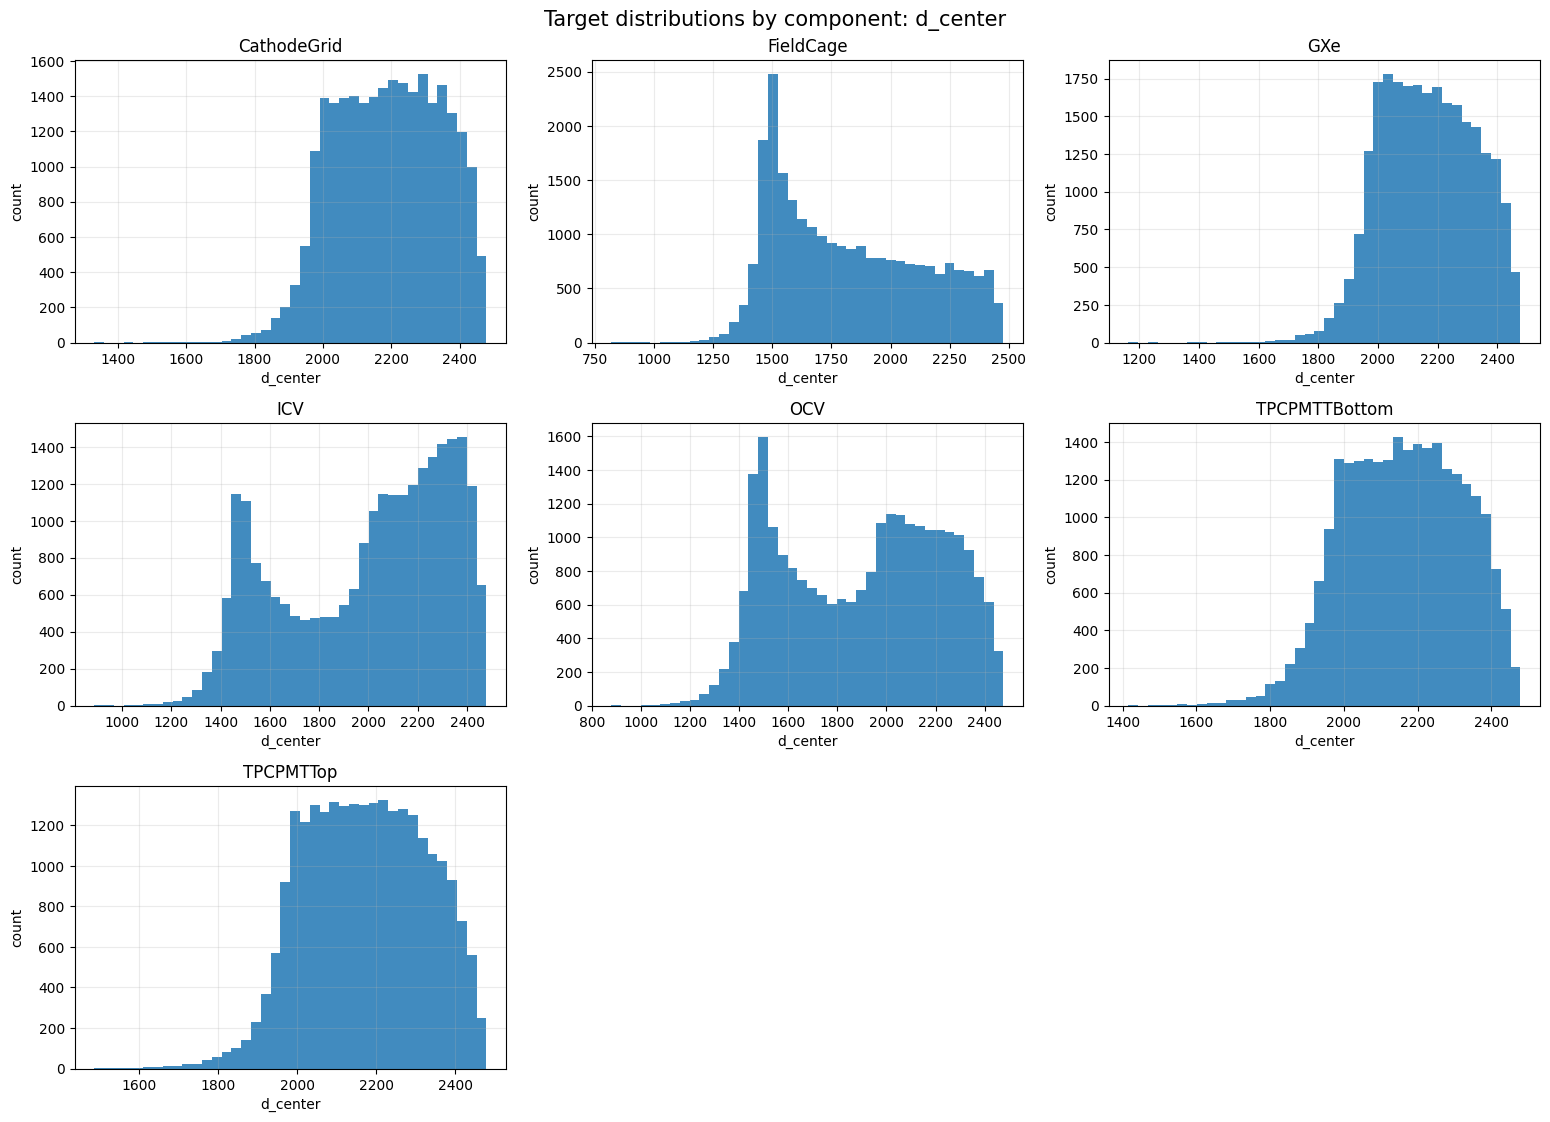

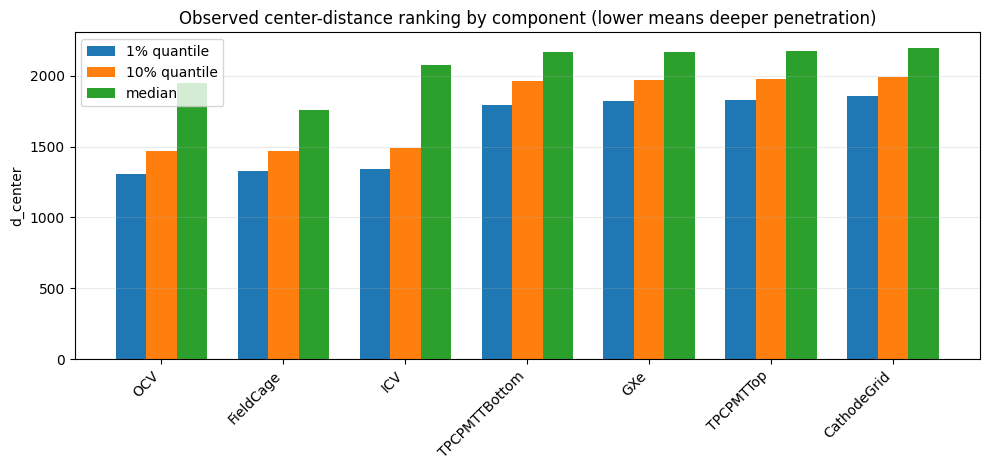

In [3]:
fig = plot_component_initial_positions(df)
display(fig)
plt.close(fig)

fig = plot_component_depth_heatmap(df, target_col="d_center")
display(fig)
plt.close(fig)

fig = plot_target_distributions(df, target_col="d_center")
display(fig)
plt.close(fig)

fig = plot_component_penetration_ranking(
    df,
    target_col="d_center",
    title="Observed center-distance ranking by component (lower means deeper penetration)",
)
display(fig)
plt.close(fig)


## 3. Train The Global Deterministic MLP Regressor

In [4]:
global_result = run_mlp_regression(
    df,
    target_name="d_center",
    model_dir=ARTIFACT_DIR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

display(pd.DataFrame([global_result.metrics]))
print(f"Saved model artifacts: {global_result.model_dir}")
print(f"Feature count: {len(global_result.feature_columns)}")


Training epochs:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/40:   0%|          | 0/274 [00:00<?, ?it/s]

Epoch 2/40:   0%|          | 0/274 [00:00<?, ?it/s]

Epoch 3/40:   0%|          | 0/274 [00:00<?, ?it/s]

Epoch 4/40:   0%|          | 0/274 [00:00<?, ?it/s]

...

Epoch 38/40:   0%|          | 0/274 [00:00<?, ?it/s]

Epoch 39/40:   0%|          | 0/274 [00:00<?, ?it/s]

Epoch 40/40:   0%|          | 0/274 [00:00<?, ?it/s]

,mae,rmse,r2,coverage_1sigma,coverage_2sigma,mean_pred_std
0,75.31274,105.026938,0.859936,0.0,0.0,0.0


Saved model artifacts: /home/klz/Data/XLZD/anpatnaik/depth_penetration_experiments/artifacts/global_center_distance_mlp
Feature count: 12


## 4. Validation Diagnostics

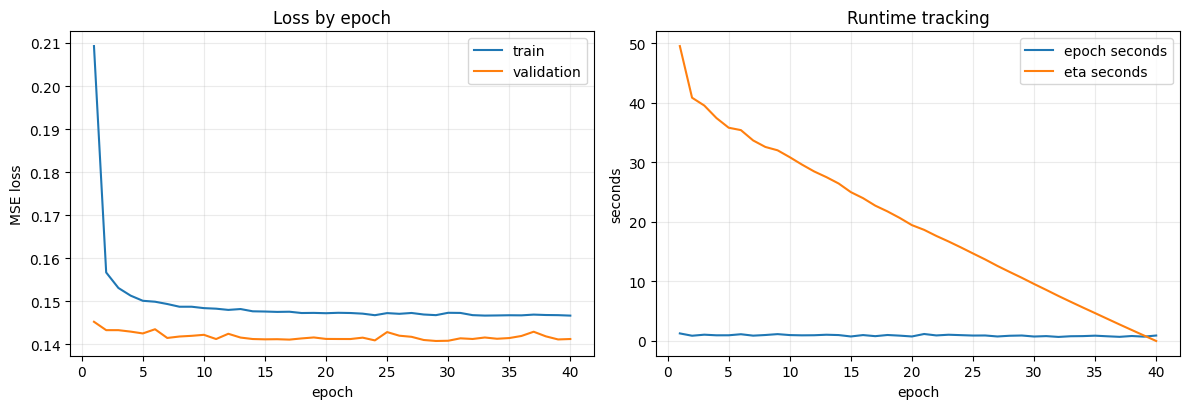

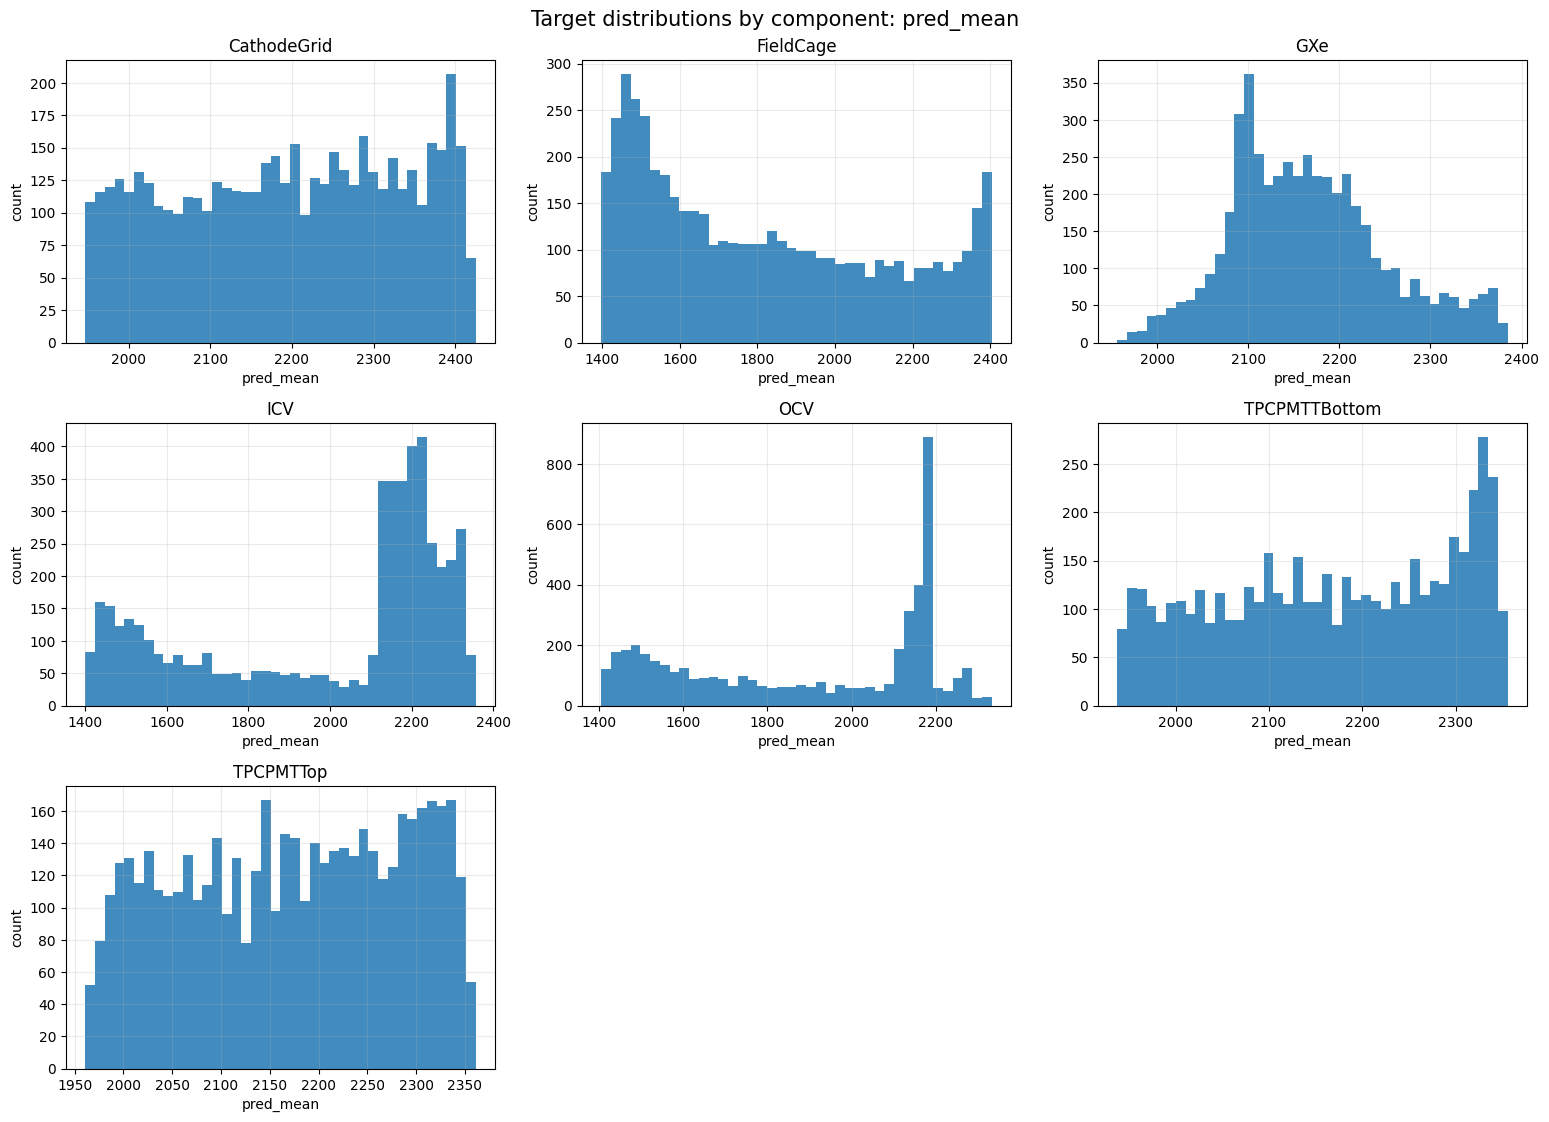

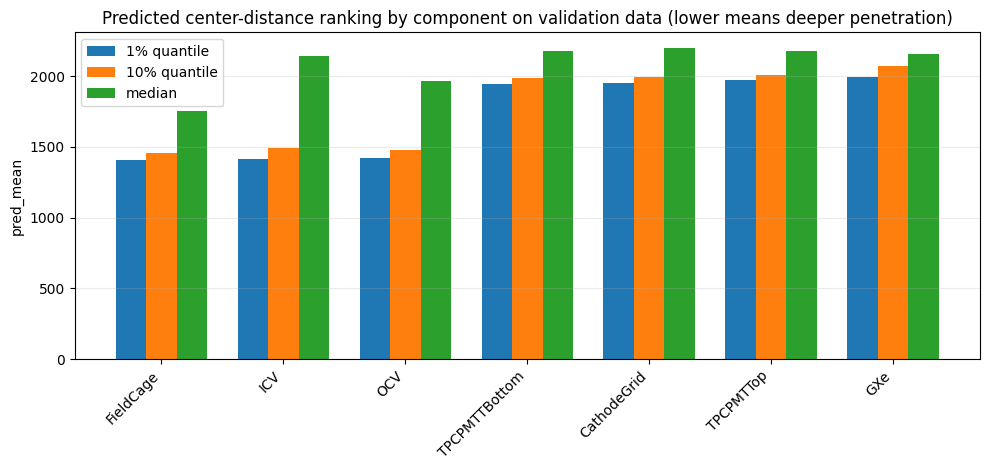

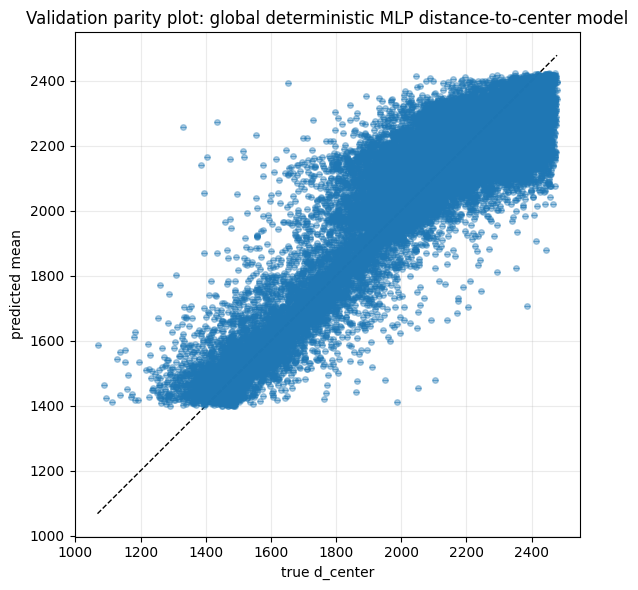

In [5]:
fig = plot_training_history(global_result.history)
display(fig)
plt.close(fig)

fig = plot_target_distributions(global_result.prediction_df, target_col="pred_mean")
display(fig)
plt.close(fig)

fig = plot_component_penetration_ranking(
    global_result.prediction_df,
    target_col="pred_mean",
    title="Predicted center-distance ranking by component on validation data (lower means deeper penetration)",
)
display(fig)
plt.close(fig)

fig = plot_prediction_parity(
    global_result.prediction_df,
    target_col="d_center",
    title="Validation parity plot: global deterministic MLP distance-to-center model",
)
display(fig)
plt.close(fig)


The deterministic MLP does not output predictive uncertainty. In this baseline, `pred_std` is stored as `0` for every validation row, so uncertainty-coverage metrics are not meaningful here. The useful comparison against VBLL is accuracy and the component-level pattern of the predictions.

In [6]:
validation_component_summary = (
    global_result.prediction_df.groupby(["source_component", "component_group"], dropna=False)
    .agg(
        validation_rows=("pred_mean", "size"),
        mean_true_d_center=("d_center", "mean"),
        mean_pred_d_center=("pred_mean", "mean"),
        mae=("abs_error", "mean"),
    )
    .reset_index()
    .sort_values("mean_true_d_center")
)
display(validation_component_summary)


,source_component,component_group,validation_rows,mean_true_d_center,mean_pred_d_center,mae
1,FieldCage,side,5000,1812.017344,1814.243854,44.266122
4,OCV,side,5000,1897.454583,1893.278666,110.845239
3,ICV,side,5000,1989.804797,1991.318400,90.125568
5,TPCPMTTBottom,bottom,5000,2162.614447,2168.859985,69.110641
2,GXe,top,5000,2168.557582,2166.147789,100.786911
6,TPCPMTTop,top,5000,2172.390468,2172.193263,71.602992
0,CathodeGrid,bottom,5000,2188.725725,2195.186399,40.451704
